#  Document Visual Question Answering (DocVQA)

Input:

    * Document image: A scanned or digital image of a document, containing text, layout, and visual elements.
    * Question about the document: A natural language question posed in text format.

Task:

    * Analyze and understand: The DocVQA model must process both the visual and textual information within the document to fully comprehend its content.
    * Reason and infer: The model needs to establish relationships between visual elements, text, and the question to draw relevant conclusions.
    * Generate a natural language answer: The model must produce a clear, concise, and accurate answer to the question in natural language text format. See the above example for the reference.

Output:

    * Answer to the question: A text response that directly addresses the query and accurately reflects the information found in the document.


In [1]:
!sudo apt install tesseract-ocr libtesseract-dev
!pip -q install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following additional packages will be installed:
  libarchive-dev libleptonica-dev
The following NEW packages will be installed:
  libarchive-dev libleptonica-dev libtesseract-dev
0 upgraded, 3 newly installed, 0 to remove and 2 not upgraded.
Need to get 581 kB/3,743 kB of archives.
After this operation, 16.0 MB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libarchive-dev amd64 3.6.0-1ubuntu1.5
Err:1 http://security.ubuntu.com/ubuntu jammy-updates/main amd64 libarchive-dev amd64 3.6.0-1ubuntu1.5
  404  Not Found [IP: 91.189.92.24 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/liba/libarchive/libarchive-dev_3.6.0-1ubuntu1.5_amd64.deb  404  Not Found [IP: 91.189.92.24 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-mis

In [2]:
import pytesseract

In [3]:
from PIL import Image
import requests

question = "What is the purchase amount?"
url =  "https://www.inv24.com/components/Misc/download/templates/en/images/purchase_invoice_template_xls-1596.jpg"
image = Image.open(requests.get(url, stream=True).raw)

In [4]:
from transformers import pipeline


pipe = pipeline("document-question-answering", model="impira/layoutlm-document-qa")# requires tesseract



out = pipe(image=image, question=question)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/205 [00:00<?, ?it/s]

LayoutLMForQuestionAnswering LOAD REPORT from: impira/layoutlm-document-qa
Key                              | Status     |  | 
---------------------------------+------------+--+-
layoutlm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'score': 0.4767009913921356, 'answer': '$1,011.00', 'start': 88, 'end': 88}]

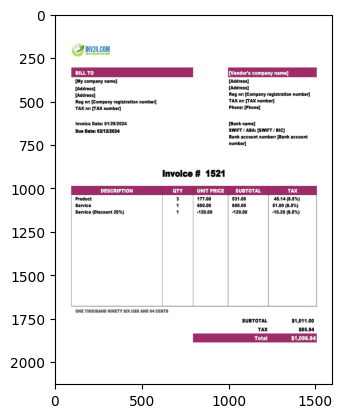

In [7]:
import matplotlib.pyplot as plt
import numpy as np
plt.imshow(np.asarray(image))
out

In [8]:


pipe_dounout = pipeline(
    "document-question-answering", model="naver-clova-ix/donut-base-finetuned-docvqa"
)



out = pipe_dounout(image=image, question=question)



Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [9]:
out

[{'answer': '$1,011.00'}]